# Shapash + TabICL for Regression

This tutorial shows how to:
- train a `TabICLRegressor` on a regression problem
- compute SHAP values with `tabicl.shap`
- convert these contributions into a format compatible with Shapash
- explore global and local explainability in a notebook
- optionally launch the Shapash WebApp

The dataset used here is `house_prices`, already provided in Shapash.

## 1. Prerequisites

TabICL does not return Shapley values directly from `predict()`.
However, the project does provide a `tabicl.shap` module that computes SHAP values by leveraging the native column-wise `NaN` masking.

Typical installation:
`pip install tabicl[shap]`

On some macOS Intel environments, you may need to install PyTorch before `tabicl`.

In [ ]:
# Uncomment if needed
# !pip install tabicl[shap]

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

from shapash import SmartExplainer
from shapash.data.data_loader import data_loading
from tabicl import TabICLRegressor
from tabicl.shap import get_shap_values, plot_shap

## 2. Load the Data

In [2]:
house_df, house_dict = data_loading('house_prices')

y = house_df['SalePrice']
X = house_df.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.75,
    random_state=42,
)

X_train.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1024,1-Story PUD (Planned Unit Development) - 1946 ...,Residential Low Density,3182,Paved,Regular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,Bloomington Heights,...,20,0,0,0,0,0,5,2008,Warranty Deed - Conventional,Normal Sale
811,1-Story 1946 & Newer All Styles,Residential Low Density,10140,Paved,Regular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,Northwest Ames,...,0,0,0,0,648,0,1,2006,Warranty Deed - Conventional,Normal Sale
1385,1-1/2 Story Finished All Ages,Residential Low Density,9060,Paved,Regular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,Edwards,...,0,0,0,0,0,0,10,2009,Warranty Deed - Conventional,Normal Sale
627,1-Story 1946 & Newer All Styles,Residential Low Density,12342,Paved,Slightly irregular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,North Ames,...,0,36,0,0,0,600,8,2007,Warranty Deed - Conventional,Normal Sale
814,1-Story 1946 & Newer All Styles,Residential Low Density,9750,Paved,Regular,Near Flat/Level,"All public Utilities (E,G,W,& S)",Inside lot,Gentle slope,North Ames,...,0,275,0,0,0,500,4,2007,Court Officer Deed/Estate,Normal Sale


## 3. Train the TabICL Model

In this version, the data is encoded numerically before `fit` (ordinal encoding of categorical variables), and missing values are imputed before training.

The model is then trained on `X_train_num` and evaluated on `X_test_num`.

In [3]:
# Replace missing values then encode categoricals to numeric before fit
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns
cat_cols = X_train.columns.difference(num_cols)

X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

num_fill_values = X_train_filled[num_cols].median()
X_train_filled[num_cols] = X_train_filled[num_cols].fillna(num_fill_values)
X_test_filled[num_cols] = X_test_filled[num_cols].fillna(num_fill_values)

if len(cat_cols) > 0:
    cat_fill_values = X_train_filled[cat_cols].mode(dropna=True).iloc[0]
    X_train_filled[cat_cols] = X_train_filled[cat_cols].fillna(cat_fill_values)
    X_test_filled[cat_cols] = X_test_filled[cat_cols].fillna(cat_fill_values)

    ordinal_encoder = OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1,
        encoded_missing_value=-1,
    )
    X_train_cat = pd.DataFrame(
        ordinal_encoder.fit_transform(X_train_filled[cat_cols]),
        index=X_train_filled.index,
        columns=cat_cols,
    )
    X_test_cat = pd.DataFrame(
        ordinal_encoder.transform(X_test_filled[cat_cols]),
        index=X_test_filled.index,
        columns=cat_cols,
    )
else:
    X_train_cat = pd.DataFrame(index=X_train_filled.index)
    X_test_cat = pd.DataFrame(index=X_test_filled.index)

X_train_num = pd.concat([X_train_filled[num_cols].astype(float), X_train_cat.astype(float)], axis=1)
X_test_num = pd.concat([X_test_filled[num_cols].astype(float), X_test_cat.astype(float)], axis=1)

# Keep the original feature order
X_train_num = X_train_num.reindex(columns=X_train.columns).fillna(0.0)
X_test_num = X_test_num.reindex(columns=X_train.columns).fillna(0.0)

regressor = TabICLRegressor(
    n_estimators=4,
    kv_cache=True,
    device='cpu',
    random_state=42,
)

regressor.fit(X_train_num, y_train)

,n_estimators,4
,norm_methods,None
,feat_shuffle_method,'latin'
,outlier_threshold,4.0
,batch_size,8
,kv_cache,True
,model_path,None
,allow_auto_download,True
,checkpoint_version,'tabicl-regressor-v2-20260212.ckpt'
,device,'cpu'
,use_amp,'auto'


In [4]:
y_pred = pd.DataFrame(regressor.predict(X_test_num), columns=['pred'], index=X_test_num.index)

metrics = pd.Series({
    'MAE': mean_absolute_error(y_test, y_pred['pred']),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred['pred'])),
    'R2': r2_score(y_test, y_pred['pred']),
})

metrics.round(4)

MAE     13479.4658
RMSE    21565.9094
R2          0.9336
dtype: float64

## 4. Compute SHAP Values with TabICL

We only explain a subset of the test set to keep the notebook responsive.

In [5]:
X_explain_columns = X_test_num.columns.tolist()

# X_explain = X_explain.fillna(0.0).astype(float)

shap_values = get_shap_values(
    estimator=regressor,
    X_test=X_test_num,
    attribute_names=X_explain_columns,
)

type(shap_values)

PermutationExplainer explainer: 366it [07:53,  1.32s/it]                         


shap._explanation.Explanation

## 5. Convert to a Shapash-Compatible Format

Shapash accepts user-provided local contributions with `SmartExplainer.compile(..., contributions=...)`.
For regression, you simply provide an `(n_samples, n_features)` matrix aligned with `x`.

In [6]:
contributions = pd.DataFrame(
    shap_values.values,
    columns=X_explain_columns,
    index=X_test_num.index,
)

contributions.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
893,1134.341146,1165.591146,-4267.718750,-243.335938,-846.552083,-1180.197917,-129.291667,-722.570312,-959.122396,-718.528646,...,-2731.927083,-1290.799479,-2229.411458,384.627604,-3934.169271,324.828125,-1374.604167,-55.851562,-1159.580729,-3525.583333
1106,2210.226562,1919.864583,4093.882812,-616.252604,54.406250,-2897.070312,-54.440104,-442.393229,-2222.575521,9676.208333,...,-975.208333,-317.333333,-2853.255208,580.546875,-7612.604167,736.776042,-1093.338542,-518.557292,-1599.414062,-5408.106771
414,-1800.076823,-1522.001302,-2821.118490,-107.744792,-535.144531,-1283.110677,-81.026042,-792.263021,-646.457031,-2638.473958,...,-2467.863281,333.020833,-2093.165365,191.466146,-3519.006510,585.395833,-988.803385,-290.632812,-970.368490,-3135.895833
523,1554.544271,-2411.419271,-11190.130208,-137.018229,-1000.174479,-2037.104167,172.817708,95.820312,-1223.960938,4175.825521,...,-1240.661458,-105.760417,-2577.388021,366.585938,-5503.609375,846.067708,301.609375,-58.408854,-1523.947917,-4321.684896
1037,801.145833,1113.877604,4766.515625,-670.895833,-154.882812,3451.523438,-229.979167,-1795.559896,-2748.388021,5653.872396,...,-2727.916667,-969.276042,-3819.666667,271.013021,-9041.513021,94.385417,709.822917,-470.518229,-2645.000000,-6211.145833


## 6. Compile SmartExplainer with TabICL Outputs

In [7]:
xpl = SmartExplainer(
    model=regressor,
    features_dict=house_dict,
    title_story='House Prices - TabICL Regressor',
)

xpl.compile(
    x=X_test_num,
    contributions=contributions,
    y_pred=y_pred,
    y_target=y_test,
)

## 7. Explainability in the Notebook

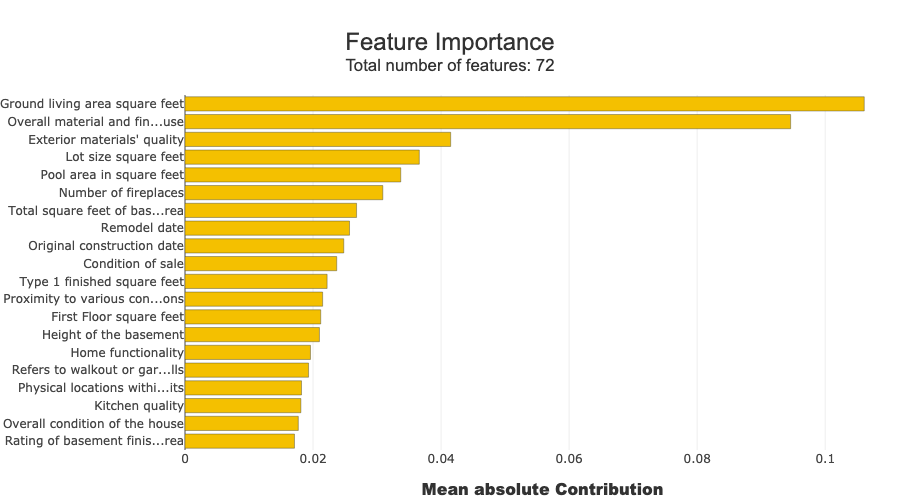

In [8]:
xpl.plot.features_importance()

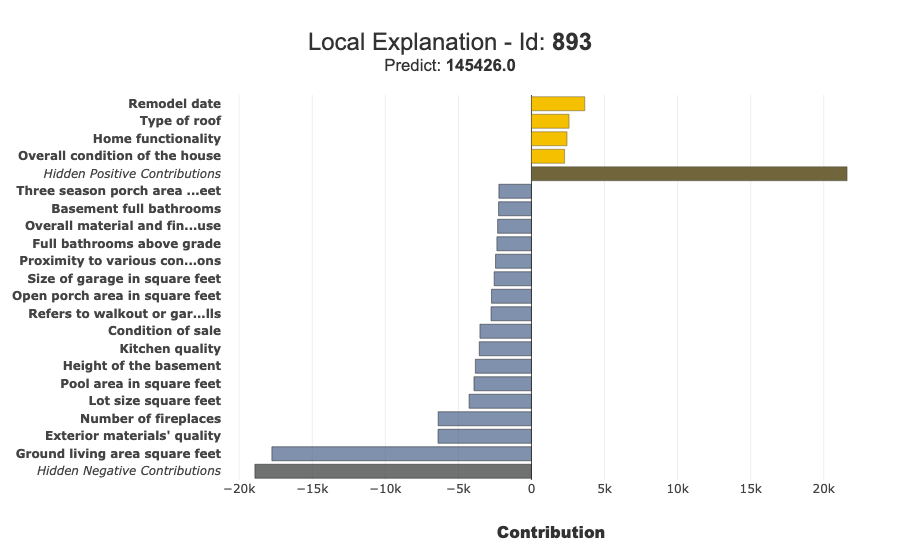

In [9]:
example_index = X_test_num.index[0]
xpl.plot.local_plot(index=example_index)

In [10]:
summary_df = xpl.to_pandas(max_contrib=4)
summary_df.head()

,pred,feature_1,value_1,contribution_1,feature_2,value_2,contribution_2,feature_3,value_3,contribution_3,feature_4,value_4,contribution_4
893,145425.593750,Ground living area square feet,1068.0,-17761.609375,Exterior materials' quality,0.0,-6394.335938,Number of fireplaces,0.0,-6384.5625,Lot size square feet,8414.0,-4267.71875
1106,338848.625000,Ground living area square feet,2622.0,63718.979167,Overall material and finish of the house,8.0,30047.625,Second floor square feet,1122.0,10486.434896,Number of fireplaces,2.0,9939.911458
414,106041.742188,Ground living area square feet,1028.0,-16405.161458,Overall material and finish of the house,5.0,-11118.700521,Proximity to various conditions,2.0,-10017.960938,Exterior materials' quality,0.0,-5917.255208
523,157701.843750,Lot size square feet,5000.0,-11190.130208,Proximity to various conditions,3.0,-10930.195312,Exterior materials' quality,0.0,-9621.018229,Number of fireplaces,2.0,9555.598958
1037,344184.750000,Overall material and finish of the house,9.0,62309.341146,Original construction date,2007.0,15426.658854,Kitchen quality,0.0,12653.299479,Total square feet of basement area,1620.0,12174.908854


## 8. Optionally Launch the WebApp

As in the other Shapash tutorials, you can launch the WebApp directly from the notebook.

In [ ]:
app = xpl.run_app(port=8050)
# Then use: app.kill()

INFO:root:Your Shapash application run on http://PMP01087:8050/
INFO:root:Use the method .kill() to down your app.
